In [1]:
# ── Cell 1: Load & Prepare ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("spatial_seer_all_rooms_v2.csv")

CHANNELS = [
    "GpuUtil", "CpuUtil", "FrameTimeStdDev", "WorstFrameMs",
    "MainThreadMs", "TotalUsedMem", "CpuClockFreq",
]
META_COLS = ["scan_id", "room_label", "location", "noise_type", "device_id", "rescan"]

# ── Split rescan=False (train) and rescan=True (test) ────────────────────────
df_train_raw = df[df["rescan"] == False].reset_index(drop=True)
df_test_raw  = df[df["rescan"] == True].reset_index(drop=True)

print(f"Train rows (rescan=False): {len(df_train_raw)}")
print(f"Test rows  (rescan=True) : {len(df_test_raw)}")
print(f"\nTest locations: {sorted(df_test_raw['location'].unique())}")
print(f"Train locations: {sorted(df_train_raw['location'].unique())}")

# ── Build per-scan arrays ─────────────────────────────────────────────────────
def build_scan_array(data: pd.DataFrame, series_len: int = None):
    records = []
    for scan_id, group in data.groupby("scan_id"):
        group = group.sort_values("Timestamp")
        if series_len:
            group = group.iloc[:series_len]
        meta = group.iloc[0]
        ts = group[CHANNELS].values.T   # (n_channels, timesteps)
        records.append({
            "scan_id":    scan_id,
            "room_label": meta["room_label"],
            "location":   meta["location"],
            "noise_type": int(meta["noise_type"]),
            "rescan":     bool(meta["rescan"]),
            "ts":         ts,
        })
    return records

# Use shortest scan length across both sets for consistency
all_scan_lengths = [
    len(g) for _, g in df.groupby("scan_id")
]
SERIES_LEN = min(all_scan_lengths)
print(f"\nSeries length (truncated to shortest scan): {SERIES_LEN}")

train_records = build_scan_array(df_train_raw, SERIES_LEN)
test_records  = build_scan_array(df_test_raw,  SERIES_LEN)

print(f"\nTrain scans: {len(train_records)}")
print(f"Test scans : {len(test_records)}")

# ── Build X and y arrays ──────────────────────────────────────────────────────
# Fit encoder on ALL 18 locations so indices are consistent
loc_enc = LabelEncoder().fit(df["location"].unique())

X_train = np.stack([r["ts"] for r in train_records])
y_train = loc_enc.transform([r["location"] for r in train_records])

X_test  = np.stack([r["ts"] for r in test_records])
y_test  = loc_enc.transform([r["location"] for r in test_records])
test_locations = [r["location"] for r in test_records]

print(f"\nX_train shape: {X_train.shape}  →  (scans, channels, timesteps)")
print(f"X_test  shape: {X_test.shape}")
print(f"\nLocation mapping:")
for cls, idx in zip(loc_enc.classes_, loc_enc.transform(loc_enc.classes_)):
    print(f"  {idx:>2}  {cls}")

Train rows (rescan=False): 9634
Test rows  (rescan=True) : 1634

Test locations: ['3215', '4001', '4211', '4213', '4214', '4218', 'Floor3Kitchen', 'Floor4Kitchen', 'privateeyelab']
Train locations: ['3211', '3215', '3310', '4001', '4211', '4213', '4214', '4218', '4307', 'CEEDKitchen', 'Floor2Kitchen', 'Floor3HallwayNearWorkArea', 'Floor3Kitchen', 'Floor4HallwayInFrontOf4214', 'Floor4Kitchen', 'InFrontOfCEEDHallway', 'Outside3102', 'Outside3410', 'privateeyelab']

Series length (truncated to shortest scan): 90

Train scans: 106
Test scans : 18

X_train shape: (106, 7, 90)  →  (scans, channels, timesteps)
X_test  shape: (18, 7, 90)

Location mapping:
   0  3211
   1  3215
   2  3310
   3  4001
   4  4211
   5  4213
   6  4214
   7  4218
   8  4307
   9  CEEDKitchen
  10  Floor2Kitchen
  11  Floor3HallwayNearWorkArea
  12  Floor3Kitchen
  13  Floor4HallwayInFrontOf4214
  14  Floor4Kitchen
  15  InFrontOfCEEDHallway
  16  Outside3102
  17  Outside3410
  18  privateeyelab


In [3]:
# ── Cell 2: MiniRocket — Train on rescan=False, Test on rescan=True ───────────
from aeon.classification.convolution_based import MiniRocketClassifier
from sklearn.metrics import accuracy_score

clf = MiniRocketClassifier(random_state=42)
print("Fitting MiniRocket on all rescan=False scans…")
clf.fit(X_train, y_train)
print("Done.\n")

y_pred = clf.predict(X_test)
pred_locations = loc_enc.inverse_transform(y_pred)
true_locations = loc_enc.inverse_transform(y_test)

# ── Per-scan breakdown ────────────────────────────────────────────────────────
results = []
for true, pred in zip(true_locations, pred_locations):
    results.append({
        "true_location": true,
        "predicted_location": pred,
        "correct": true == pred,
    })
results_df = pd.DataFrame(results)

overall_acc = accuracy_score(y_test, y_pred)
print(f"Overall accuracy: {overall_acc:.4f}  ({results_df['correct'].sum()}/{len(results_df)} correct)\n")
print(results_df.to_string(index=False))

Fitting MiniRocket on all rescan=False scans…
Done.

Overall accuracy: 0.3333  (6/18 correct)

true_location predicted_location  correct
         4001               4214    False
         4001               4001     True
         4211        CEEDKitchen    False
         4211      privateeyelab    False
         4218               3310    False
         4218               3310    False
Floor3Kitchen      Floor3Kitchen     True
Floor3Kitchen      Floor2Kitchen    False
Floor4Kitchen      Floor3Kitchen    False
Floor4Kitchen      Floor3Kitchen    False
         3215               4213    False
         3215               4213    False
         4213      Floor2Kitchen    False
         4213               3215    False
         4214               4214     True
         4214               4214     True
privateeyelab      privateeyelab     True
privateeyelab      privateeyelab     True


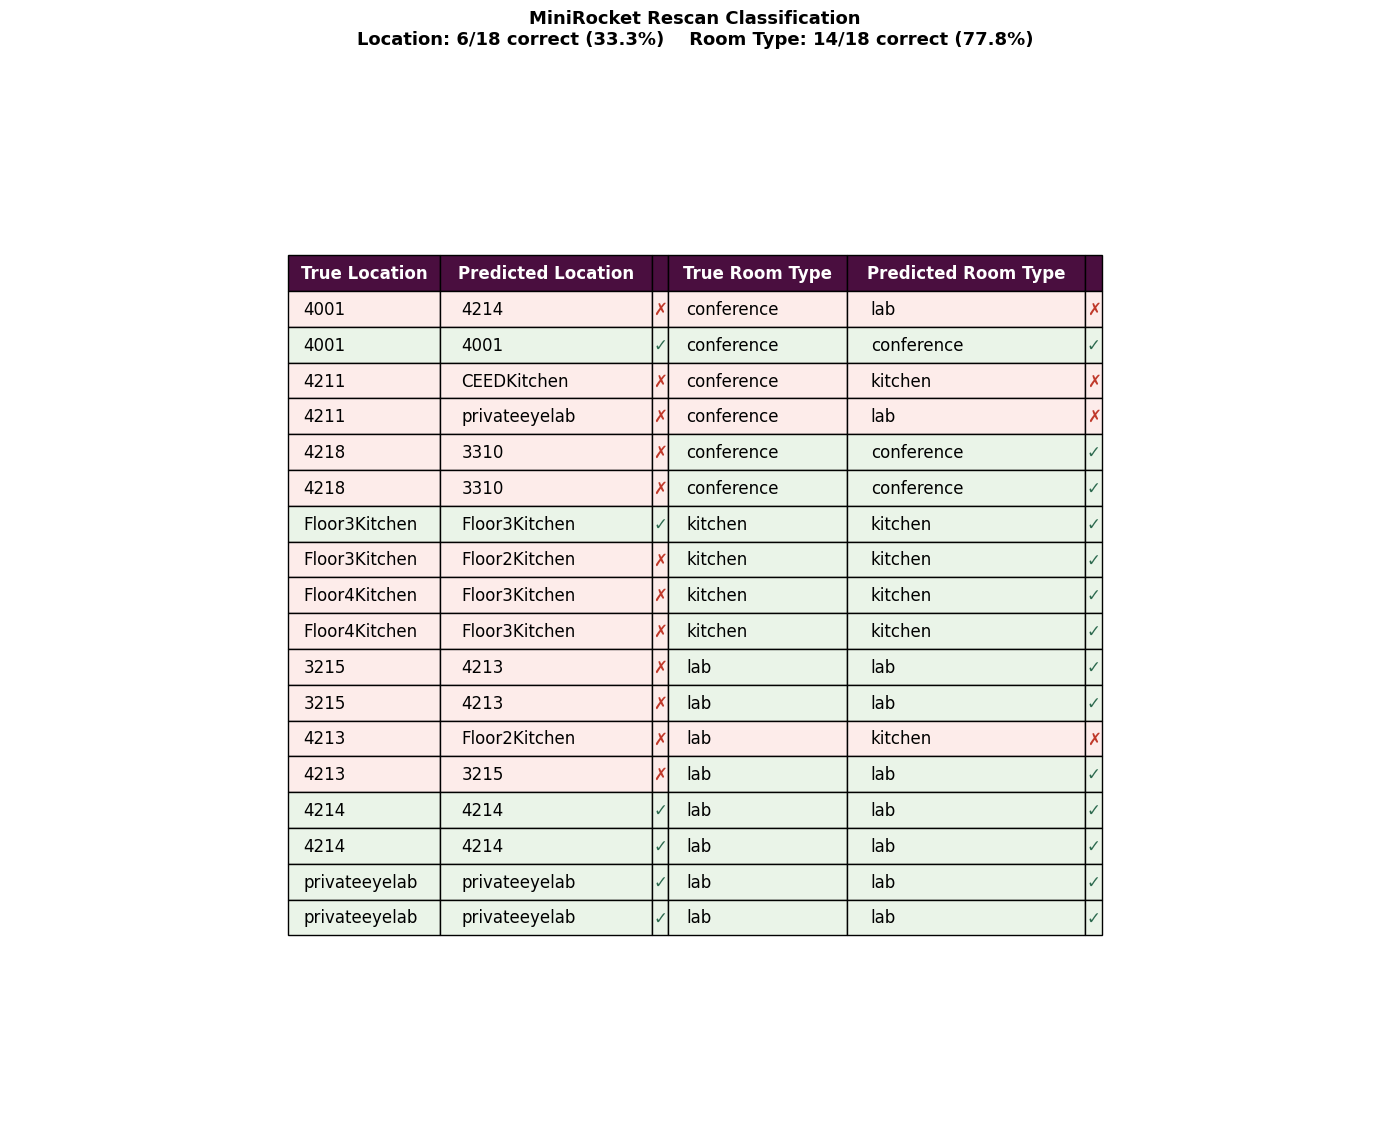

In [5]:
# ── Cell 3: Results Table with Room Type ─────────────────────────────────────

# Build a location → room_label lookup from the full dataset
loc_to_room = df.drop_duplicates("location").set_index("location")["room_label"].to_dict()

table_data = []
for _, r in results_df.iterrows():
    true_room = loc_to_room.get(r["true_location"], "?")
    pred_room = loc_to_room.get(r["predicted_location"], "?")
    loc_correct  = r["correct"]
    room_correct = true_room == pred_room
    table_data.append({
        "true_location":   r["true_location"],
        "pred_location":   r["predicted_location"],
        "loc_correct":     loc_correct,
        "true_room":       true_room,
        "pred_room":       pred_room,
        "room_correct":    room_correct,
    })

table_df = pd.DataFrame(table_data)

fig, ax = plt.subplots(figsize=(14, len(table_df) * 0.55 + 1.5))
ax.axis("off")

cell_text = [
    [
        r["true_location"],
        r["pred_location"],
        "✓" if r["loc_correct"]  else "✗",
        r["true_room"],
        r["pred_room"],
        "✓" if r["room_correct"] else "✗",
    ]
    for _, r in table_df.iterrows()
]

col_labels = ["True Location", "Predicted Location", "", "True Room Type", "Predicted Room Type", ""]

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    loc="center",
    cellLoc="left",
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.8)

# Header styling
for j in range(6):
    table[0, j].set_facecolor("#4a0e3f")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Data row styling
GREEN_BG  = "#eaf4e8"
RED_BG    = "#fdecea"
GREEN_FG  = "#2d6a4f"
RED_FG    = "#c0392b"

for i, row in table_df.iterrows():
    # Location columns (0, 1, 2)
    loc_bg = GREEN_BG if row["loc_correct"] else RED_BG
    for j in range(3):
        table[i + 1, j].set_facecolor(loc_bg)
    table[i + 1, 2].set_text_props(
        color=GREEN_FG if row["loc_correct"] else RED_FG,
        fontweight="bold",
    )

    # Room type columns (3, 4, 5)
    room_bg = GREEN_BG if row["room_correct"] else RED_BG
    for j in range(3, 6):
        table[i + 1, j].set_facecolor(room_bg)
    table[i + 1, 5].set_text_props(
        color=GREEN_FG if row["room_correct"] else RED_FG,
        fontweight="bold",
    )

table.auto_set_column_width([0, 1, 2, 3, 4, 5])

loc_correct_count  = table_df["loc_correct"].sum()
room_correct_count = table_df["room_correct"].sum()
total = len(table_df)

ax.set_title(
    f"MiniRocket Rescan Classification\n"
    f"Location: {loc_correct_count}/{total} correct ({loc_correct_count/total:.1%})    "
    f"Room Type: {room_correct_count}/{total} correct ({room_correct_count/total:.1%})",
    fontsize=13, fontweight="bold", pad=20,
)
plt.tight_layout()
plt.show()